# 🎬 Netflix Content Library — Exploratory Data Analysis

**A Mini Project on Data Cleaning, Exploratory Data Analysis, Feature Engineering and Business Insight Generation**

---

### Objective
Explore the Netflix titles dataset to answer key business questions about content type, geographic
distribution, release trends, ratings, genres, duration and outliers — and translate the findings into
actionable recommendations for Netflix's content strategy team.

### Dataset
`NetFlix.csv` — 7,787 titles (Movies & TV Shows) available on Netflix, with 12 attributes:
`show_id, type, title, director, cast, country, date_added, release_year, rating, duration, genres, description`

### Tools Used
`pandas`, `numpy`, `matplotlib`, `seaborn`, `scipy`

### Structure
The notebook is organised into 13 tasks, each ending with a short **Interpretation** so every
chart/table is tied back to a business-relevant takeaway.


## Table of Contents
1. [Dataset Understanding](#Task-1:-Dataset-Understanding)
2. [Data Cleaning](#Task-2:-Data-Cleaning)
3. [Content Type Analysis](#Task-3:-Content-Type-Analysis)
4. [Country Analysis](#Task-4:-Country-Analysis)
5. [Yearly Trend Analysis](#Task-5:-Yearly-Trend-Analysis)
6. [Rating Analysis](#Task-6:-Rating-Analysis)
7. [Genre Analysis](#Task-7:-Genre-Analysis)
8. [Duration Analysis](#Task-8:-Duration-Analysis)
9. [Outlier Analysis](#Task-9:-Outlier-Analysis)
10. [Feature Engineering](#Task-10:-Feature-Engineering)
11. [Multivariate Analysis](#Task-11:-Multivariate-Analysis)
12. [Business Insights & Recommendations](#Task-12:-Business-Insights)
13. [Conclusion](#Task-13:-Conclusion)


In [1]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore
import warnings

warnings.filterwarnings('ignore')

# Consistent, Netflix-themed visual style used for every chart in this notebook
sns.set_theme(style='whitegrid')
NETFLIX_RED  = '#E50914'
NETFLIX_DARK = '#221f1f'
PALETTE      = ['#E50914', '#B81D24', '#221f1f', '#831010', '#564d4d', '#F5F5F1']
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'

pd.set_option('display.max_columns', None)


# Task 1: Dataset Understanding

In [2]:
df = pd.read_csv("NetFlix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genres,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,14-Aug-20,2020,TV-MA,4,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s10,Movie,1920,Vikram Bhatt,"Rajneesh Duggal, Adah Sharma, Indraneil Sengup...",India,15-Dec-17,2008,TV-MA,143,"Horror Movies, International Movies, Thrillers",An architect and his wife move into a castle t...
2,s100,Movie,3 Heroines,Iman Brotoseno,"Reza Rahadian, Bunga Citra Lestari, Tara Basro...",Indonesia,5-Jan-19,2016,TV-PG,124,"Dramas, International Movies, Sports Movies",Three Indonesian women break records by becomi...
3,s1000,Movie,Blue Mountain State: The Rise of Thadland,Lev L. Spiro,"Alan Ritchson, Darin Brooks, James Cade, Rob R...",United States,1-Mar-16,2016,R,90,Comedies,New NFL star Thad buys his old teammates' belo...
4,s1001,TV Show,Blue Planet II,NaN,David Attenborough,United Kingdom,3-Dec-18,2017,TV-G,1,"British TV Shows, Docuseries, Science & Nature TV",This sequel to the award-winning nature series...


In [3]:
df.shape

(7787, 12)

In [4]:
df.columns

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genres', 'description'],
      dtype='str')

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   int64
 10  genres        7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(2), str(10)
memory usage: 730.2 KB


## Observation
- Most columns are `object` dtype (text).
- `release_year` and `duration` are integers.
- `director`, `cast`, `country`, `date_added` and `rating` contain missing values.
- `duration` is a single numeric column but represents **two different units**: minutes for Movies and
  number of seasons for TV Shows. This matters — it must never be averaged or plotted across both types
  together (a mistake we deliberately avoid in Task 8 and Task 10).

In [6]:
df.describe()

,release_year,duration
count,7787.000000,7787.000000
mean,2013.932580,69.122769
std,8.757395,50.950743
min,1925.000000,1.000000
25%,2013.000000,2.000000
50%,2017.000000,88.000000
75%,2018.000000,106.000000
max,2021.000000,312.000000


In [7]:
df.describe(include='object')

,show_id,type,title,director,cast,country,date_added,rating,genres,description
count,7787,7787,7787,5398,7069,7280,7777,7780,7787,7787
unique,7787,2,7787,4049,6831,681,1512,14,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,1-Jan-20,TV-MA,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,119,2863,334,3


## Purpose of `describe()`
- `describe()` (numeric) → count, mean, std, min/max, quartiles for numeric columns.
- `describe(include='object')` → count, number of unique values, most frequent value (`top`), and its
  frequency (`freq`) for text/categorical columns.

In [8]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

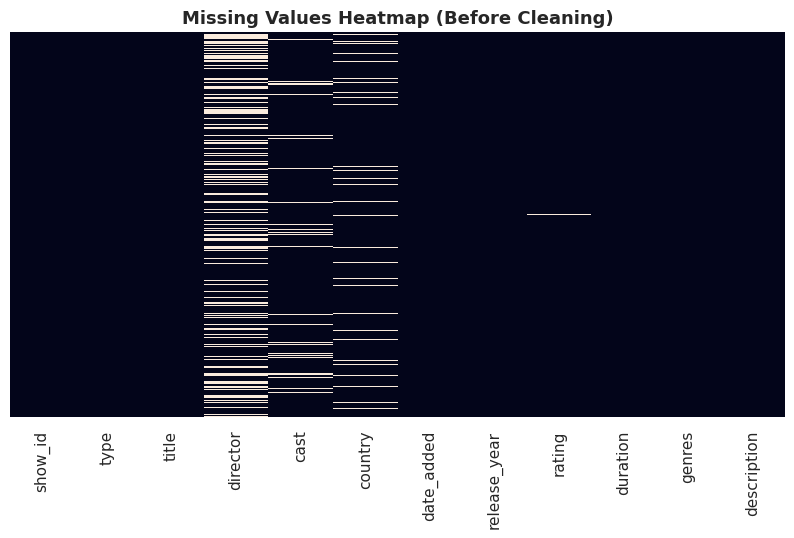

In [9]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False,
    cmap='rocket'
)

plt.title("Missing Values Heatmap (Before Cleaning)")
plt.show()

### Missing values, visually.
Light/colored streaks mark null cells — `director`, `cast` and `country` stand out clearly.

In [10]:
df.duplicated().sum()

np.int64(0)

In [11]:
for col in df.columns:
    print(f"{col:15s}: {df[col].nunique()} unique values")

show_id        : 7787 unique values
type           : 2 unique values
title          : 7787 unique values
director       : 4049 unique values
cast           : 6831 unique values
country        : 681 unique values
date_added     : 1512 unique values
release_year   : 73 unique values
rating         : 14 unique values
duration       : 206 unique values
genres         : 492 unique values
description    : 7769 unique values


## Findings
- Dataset contains **7,787** Netflix titles.
- There are **12 features** describing content information.
- Missing values exist mainly in: **director**, **cast**, **country**, **date_added**, **rating**.
- Dataset contains both numerical and categorical variables.
- No duplicate rows.
- Data is suitable for: content-type analysis, country analysis, trend analysis, genre analysis,
  rating analysis, duration/outlier analysis and feature engineering.

# Task 2: Data Cleaning

In [12]:
# Always keep the original dataset untouched — all cleaning happens on a copy.
df_clean = df.copy()

In [13]:
df_clean.isnull().sum()

show_id            0
type               0
title              0
director        2389
cast             718
country          507
date_added        10
release_year       0
rating             7
duration           0
genres             0
description        0
dtype: int64

In [14]:
# director: majority of rows have no director listed -> explicit 'Unknown' category
df_clean['director'] = df_clean['director'].fillna('Unknown')

# cast: no cast credited
df_clean['cast'] = df_clean['cast'].fillna('Not Available')

# country: production country not recorded
df_clean['country'] = df_clean['country'].fillna('Unknown')

# rating: very few missing values -> safe to impute with the mode
df_clean['rating'] = df_clean['rating'].fillna(df_clean['rating'].mode()[0])

# date_added: very few missing values -> safe to impute with the mode
df_clean['date_added'] = df_clean['date_added'].fillna(df_clean['date_added'].mode()[0])

In [15]:
df_clean.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
genres          0
description     0
dtype: int64

In [16]:
df_clean.duplicated().sum()

np.int64(0)

### Converting the Date Column

In [17]:
df_clean['date_added'] = pd.to_datetime(
    df_clean['date_added'],
    format='mixed',
    dayfirst=True
)

df_clean['added_year']       = df_clean['date_added'].dt.year        # Year added to Netflix
df_clean['added_month']      = df_clean['date_added'].dt.month       # Month added (numeric)
df_clean['added_month_name'] = df_clean['date_added'].dt.month_name()  # Month added (name)

### Data Quality Check — Timeline Consistency
A title should never be *added* to Netflix before it was *released*. This is a quick sanity check that
a raw, un-vetted CSV can hide inconsistencies of this kind.

In [18]:
timeline_issues = df_clean[df_clean['added_year'] < df_clean['release_year']]

print("Rows where 'added_year' is earlier than 'release_year':", len(timeline_issues))
timeline_issues[['title', 'release_year', 'added_year']].head()

Rows where 'added_year' is earlier than 'release_year': 12


,title,release_year,added_year
31,BoJack Horseman,2020,2019
1460,Fuller House,2020,2019
1783,Hans Teeuwen: Real Rancour,2018,2017
1937,Hilda,2021,2020
2203,Incoming,2019,2018


**Note:** a handful of rows show `added_year < release_year`. This happens because `release_year`
sometimes reflects a *re-release* or *festival premiere* year that pre-dates the title's Netflix listing
date recorded in the source metadata — not a data error requiring correction here, but worth flagging for
any downstream analysis that relies on strict chronological ordering.

### Understanding the `duration` Column
Recall from Task 1: `duration` mixes two units depending on `type`. We inspect this explicitly before
using the column anywhere.

In [19]:
df_clean[['type', 'duration']].head(10)

,type,duration
0,TV Show,4
1,Movie,143
2,Movie,124
3,Movie,90
4,TV Show,1
5,Movie,90
6,Movie,94
7,Movie,112
8,Movie,129
9,Movie,85


In [20]:
print("Duration range for Movies :", df_clean.loc[df_clean['type'] == 'Movie', 'duration'].min(),
      "-", df_clean.loc[df_clean['type'] == 'Movie', 'duration'].max(), "minutes")
print("Duration range for TV Shows :", df_clean.loc[df_clean['type'] == 'TV Show', 'duration'].min(),
      "-", df_clean.loc[df_clean['type'] == 'TV Show', 'duration'].max(), "seasons")

Duration range for Movies : 3 - 312 minutes
Duration range for TV Shows : 1 - 16 seasons


Confirmed: for **Movies**, `duration` is minutes; for **TV Shows**, `duration` is the number of seasons. We will always split by `type` before doing arithmetic on this column.

## Standardizing Text Columns

In [21]:
text_cols = ['title', 'director', 'cast', 'country', 'rating', 'genres']

for col in text_cols:
    df_clean[col] = df_clean[col].str.strip()

In [22]:
df_clean.info()

<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           7787 non-null   str           
 1   type              7787 non-null   str           
 2   title             7787 non-null   str           
 3   director          7787 non-null   str           
 4   cast              7787 non-null   str           
 5   country           7787 non-null   str           
 6   date_added        7787 non-null   datetime64[us]
 7   release_year      7787 non-null   int64         
 8   rating            7787 non-null   str           
 9   duration          7787 non-null   int64         
 10  genres            7787 non-null   str           
 11  description       7787 non-null   str           
 12  added_year        7787 non-null   int32         
 13  added_month       7787 non-null   int32         
 14  added_month_name  7787 non-null   s

# Task 3: Content Type Analysis

## 1. Count Content Types

In [23]:
df_clean['type'].value_counts()

type
Movie      5377
TV Show    2410
Name: count, dtype: int64

## 2. Number of Movies

In [24]:
movies_count = df_clean[df_clean['type'] == 'Movie'].shape[0]
print("Total Movies:", movies_count)

Total Movies: 5377


## 3. Number of TV Shows

In [25]:
tv_count = df_clean[df_clean['type'] == 'TV Show'].shape[0]
print("Total TV Shows:", tv_count)

Total TV Shows: 2410


## 4. Percentage Distribution

In [26]:
content_pct = round(df_clean['type'].value_counts(normalize=True) * 100, 2)
content_pct

type
Movie      69.05
TV Show    30.95
Name: proportion, dtype: float64

## 5. Count Plot

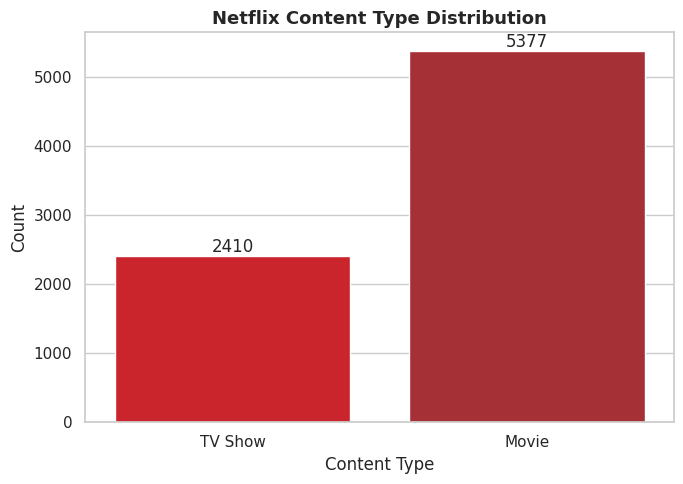

In [27]:
plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df_clean,
    x='type',
    hue='type',
    palette=PALETTE[:2],
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Netflix Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

## 6. Pie Chart

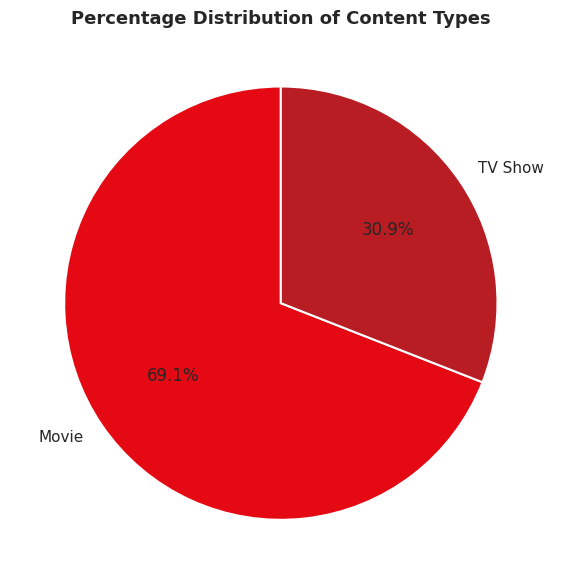

In [28]:
content_counts = df_clean['type'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    content_counts,
    labels=content_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=PALETTE[:2],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
plt.title("Percentage Distribution of Content Types")
plt.tight_layout()
plt.show()

## Interpretation
- Netflix contains **5,377 Movies** and **2,410 TV Shows** (see `movies_count` / `tv_count` above).
- Movies account for roughly **69%** of the platform's content, TV Shows for **31%**.
- The platform has more than twice as many Movies as TV Shows — the content library is heavily
  movie-oriented, which has implications for licensing spend and content-acquisition strategy.

# Task 4: Country Analysis

## Questions
1. Top 10 content-producing countries.
2. Visualize country distribution.

In [29]:
df_clean['country'].head()

0            Brazil
1             India
2         Indonesia
3     United States
4    United Kingdom
Name: country, dtype: str

In [30]:
# A title can list several co-producing countries (comma-separated).
# For "who produces the most content" we take the FIRST listed country as the primary producer.
df_clean['primary_country'] = (
    df_clean['country']
    .str.split(',')
    .str[0]
    .str.strip()
)

In [31]:
top_countries = df_clean['primary_country'].value_counts().head(10)
top_countries

primary_country
United States     2883
India              956
United Kingdom     577
Unknown            507
Canada             259
Japan              237
France             196
South Korea        194
Spain              168
Mexico             123
Name: count, dtype: int64

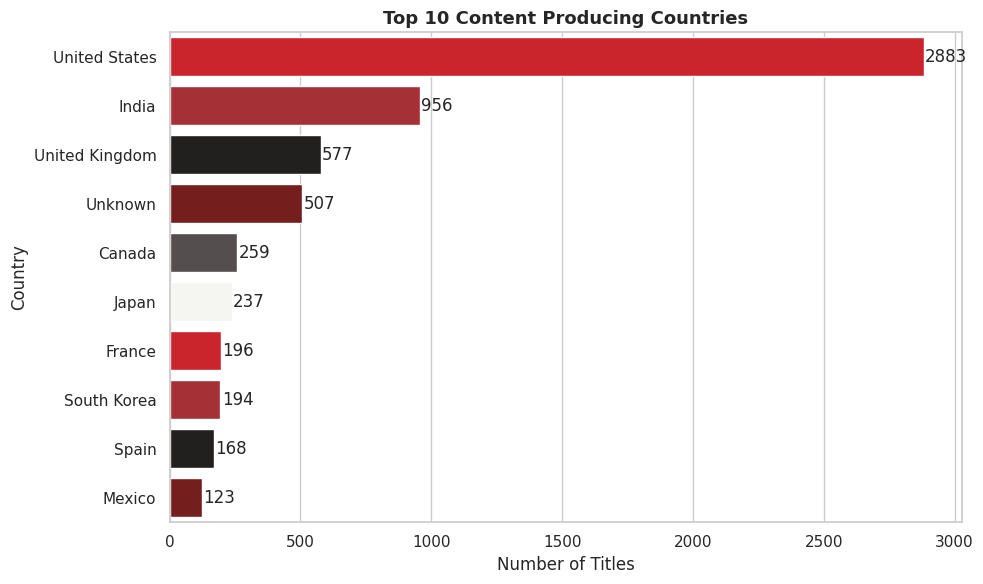

In [32]:
plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette=PALETTE * 2,
    legend=False
)

for i, v in enumerate(top_countries.values):
    ax.text(v + 5, i, str(v), va='center')

plt.title("Top 10 Content Producing Countries")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

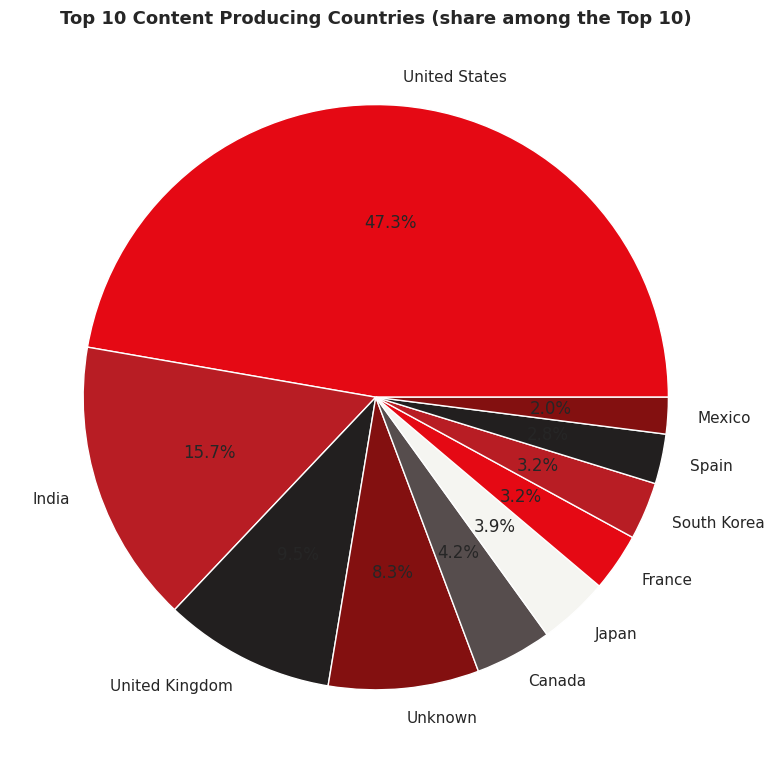

In [33]:
plt.figure(figsize=(8, 8))
plt.pie(
    top_countries.values,
    labels=top_countries.index,
    autopct='%1.1f%%',
    colors=PALETTE * 2,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
plt.title("Top 10 Content Producing Countries (share among the Top 10)")
plt.tight_layout()
plt.show()

In [34]:
country_df = df_clean['primary_country'].value_counts().reset_index()
country_df.columns = ['Country', 'Count']
country_df.head(10)

,Country,Count
0,United States,2883
1,India,956
2,United Kingdom,577
3,Unknown,507
4,Canada,259
5,Japan,237
6,France,196
7,South Korea,194
8,Spain,168
9,Mexico,123


### Extra depth -- co-production countries
Looking only at the *primary* country hides collaborations. Exploding **all** listed countries per title
gives a fuller picture of where Netflix content is produced, including as a co-producer.

In [35]:
all_countries = (
    df_clean['country']
    .str.split(',')
    .explode()
    .str.strip()
)
all_countries = all_countries[all_countries != 'Unknown']

top_all_countries = all_countries.value_counts().head(10)
top_all_countries

country
United States     3297
India              990
United Kingdom     723
Canada             412
France             349
Japan              287
Spain              215
South Korea        212
Germany            199
Mexico             154
Name: count, dtype: int64

## Interpretation
### Key Findings
1. The United States dominates Netflix content production with **2,883** titles as primary producer.
2. India is the second-largest contributor with **956** titles.
3. The United Kingdom ranks third with **577** titles.
4. Asian countries such as India, Japan and South Korea contribute significantly to the platform.
5. More than 500 records have missing country information (shown as *Unknown*).
6. When co-production credits are counted (not just the primary country), the same top countries
   remain dominant, but several European countries move up -- showing Netflix's reliance on
   international co-production deals, not just single-country originals.
7. India's position as the second-largest content producer highlights the importance of the Indian
   entertainment market and Netflix's investment in regional content.

# Task 5: Yearly Trend Analysis

## Questions
1. Number of titles released each year.
2. Has content production increased over time?

In [36]:
yearly_titles = df_clean['release_year'].value_counts().sort_index()
yearly_titles.head()

release_year
1925    1
1942    2
1943    3
1944    3
1945    3
Name: count, dtype: int64

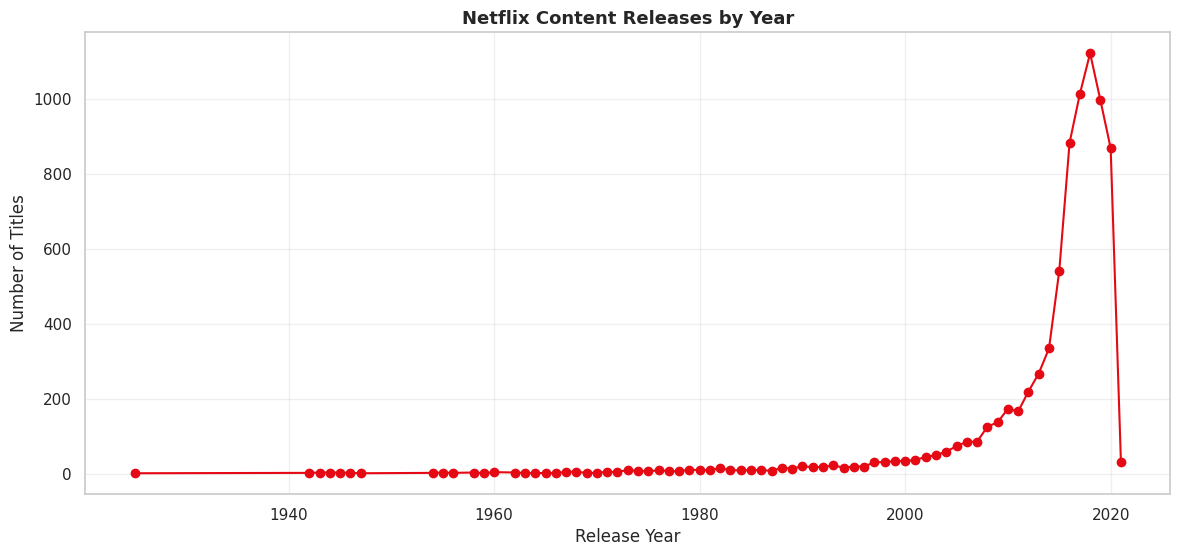

In [37]:
plt.figure(figsize=(14, 6))
plt.plot(yearly_titles.index, yearly_titles.values, marker='o', color=NETFLIX_RED)
plt.title("Netflix Content Releases by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.grid(True, alpha=0.3)
plt.show()

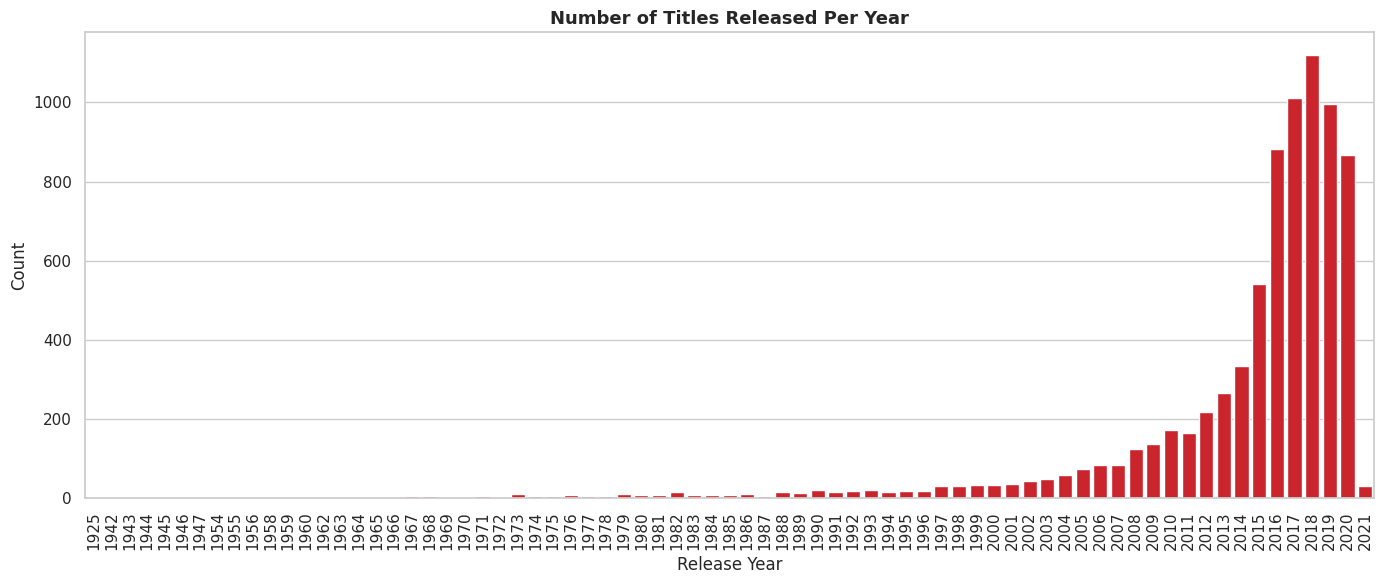

In [38]:
plt.figure(figsize=(14, 6))
sns.barplot(x=yearly_titles.index, y=yearly_titles.values, color=NETFLIX_RED)
plt.xticks(rotation=90)
plt.title("Number of Titles Released Per Year")
plt.xlabel("Release Year")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [39]:
peak_year = yearly_titles.idxmax()
peak_count = yearly_titles.max()
print("Peak Year:", peak_year)
print("Titles Released:", peak_count)

Peak Year: 2018
Titles Released: 1121


In [40]:
recent_trend = (
    df_clean[df_clean['release_year'] >= 2010]['release_year']
    .value_counts()
    .sort_index()
)
recent_trend

release_year
2010     173
2011     166
2012     219
2013     267
2014     334
2015     541
2016     882
2017    1012
2018    1121
2019     996
2020     868
2021      31
Name: count, dtype: int64

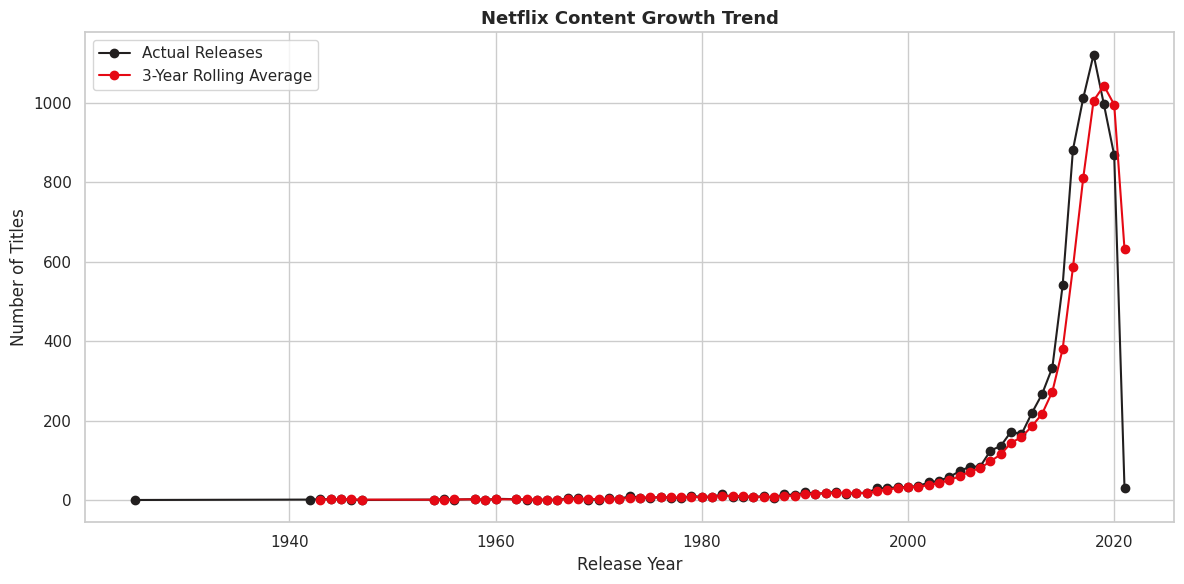

In [41]:
yearly_df = yearly_titles.reset_index()
yearly_df.columns = ['Year', 'Count']
yearly_df['Rolling_Avg'] = yearly_df['Count'].rolling(3).mean()

plt.figure(figsize=(12, 6))
plt.plot(yearly_df['Year'], yearly_df['Count'], marker='o', label='Actual Releases', color=NETFLIX_DARK)
plt.plot(yearly_df['Year'], yearly_df['Rolling_Avg'], marker='o', label='3-Year Rolling Average', color=NETFLIX_RED)
plt.title("Netflix Content Growth Trend")
plt.xlabel("Release Year")
plt.ylabel("Number of Titles")
plt.legend()
plt.tight_layout()
plt.show()

## Interpretation
### Key Findings
1. Netflix content production increased steadily from 2007 to 2018.
2. The most significant growth occurred between 2015 and 2018.
3. Content production peaked in 2018 with **1,121** titles.
4. After 2018, the number of releases declined in the raw counts.
5. The very low count for 2021 reflects that the dataset was collected before that year was complete --
   not an actual production slowdown.

# Task 6: Rating Analysis

## Questions
1. Most common maturity rating.
2. Distribution of ratings.
3. Visualization using countplots.

In [42]:
rating_counts = df_clean['rating'].value_counts()
rating_counts

rating
TV-MA       2870
TV-14       1931
TV-PG        806
R            665
PG-13        386
TV-Y         280
TV-Y7        271
PG           247
TV-G         194
NR            84
G             39
TV-Y7-FV       6
UR             5
NC-17          3
Name: count, dtype: int64

In [43]:
most_common_rating = df_clean['rating'].mode()[0]
print("Most Common Rating:", most_common_rating)

Most Common Rating: TV-MA


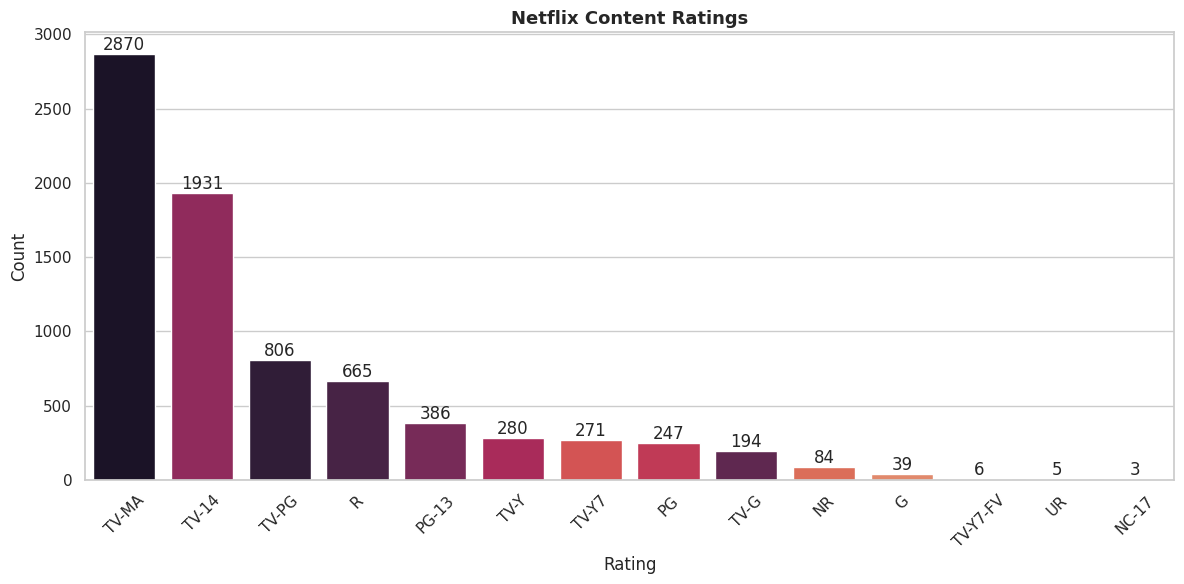

In [44]:
plt.figure(figsize=(12, 6))

ax = sns.countplot(
    data=df_clean,
    x='rating',
    hue='rating',
    order=df_clean['rating'].value_counts().index,
    palette='rocket',
    legend=False
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Netflix Content Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

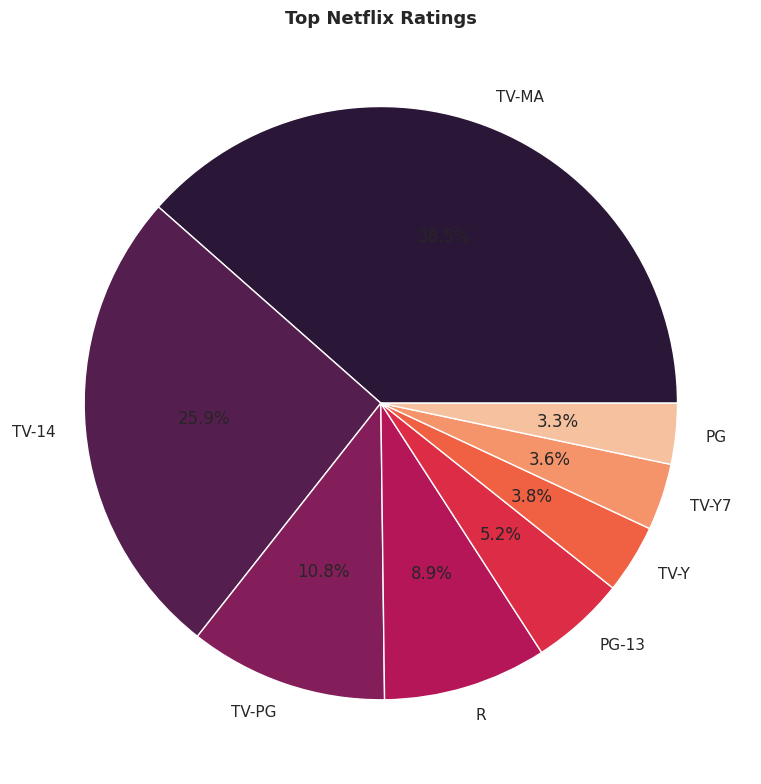

In [45]:
top_ratings = df_clean['rating'].value_counts().head(8)

plt.figure(figsize=(8, 8))
plt.pie(
    top_ratings.values,
    labels=top_ratings.index,
    autopct='%1.1f%%',
    colors=sns.color_palette('rocket', len(top_ratings)),
    wedgeprops={'edgecolor': 'white', 'linewidth': 1}
)
plt.title("Top Netflix Ratings")
plt.tight_layout()
plt.show()

## Interpretation
### Key Findings
1. **TV-MA** is the most common rating with **2,870** titles.
2. **TV-14** is the second most frequent rating with **1,931** titles.
3. Most Netflix content is intended for teenagers and adults.
4. Children's content (TV-Y, TV-Y7, TV-G) represents a much smaller portion of the catalog.
5. Mature content dominates the platform -- worth noting for family-plan positioning and parental-control
   messaging.

# Task 7: Genre Analysis

## Questions
1. Top 10 genres.
2. Most popular genre category.
3. Visualize findings.

In [46]:
df_clean['genres'].head(10)

0    International TV Shows, TV Dramas, TV Sci-Fi &...
1       Horror Movies, International Movies, Thrillers
2          Dramas, International Movies, Sports Movies
3                                             Comedies
4    British TV Shows, Docuseries, Science & Nature TV
5                        Independent Movies, Thrillers
6                         Action & Adventure, Comedies
7          Dramas, Independent Movies, Romantic Movies
8      Comedies, International Movies, Romantic Movies
9                                        Documentaries
Name: genres, dtype: str

In [47]:
genre_series = (
    df_clean['genres']
    .str.split(',')
    .explode()
    .str.strip()
)

In [48]:
genre_counts = genre_series.value_counts()
genre_counts.head(10)

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64

In [49]:
top10_genres = genre_counts.head(10)
print(top10_genres)

genres
International Movies        2437
Dramas                      2106
Comedies                    1471
International TV Shows      1199
Documentaries                786
Action & Adventure           721
TV Dramas                    704
Independent Movies           673
Children & Family Movies     532
Romantic Movies              531
Name: count, dtype: int64


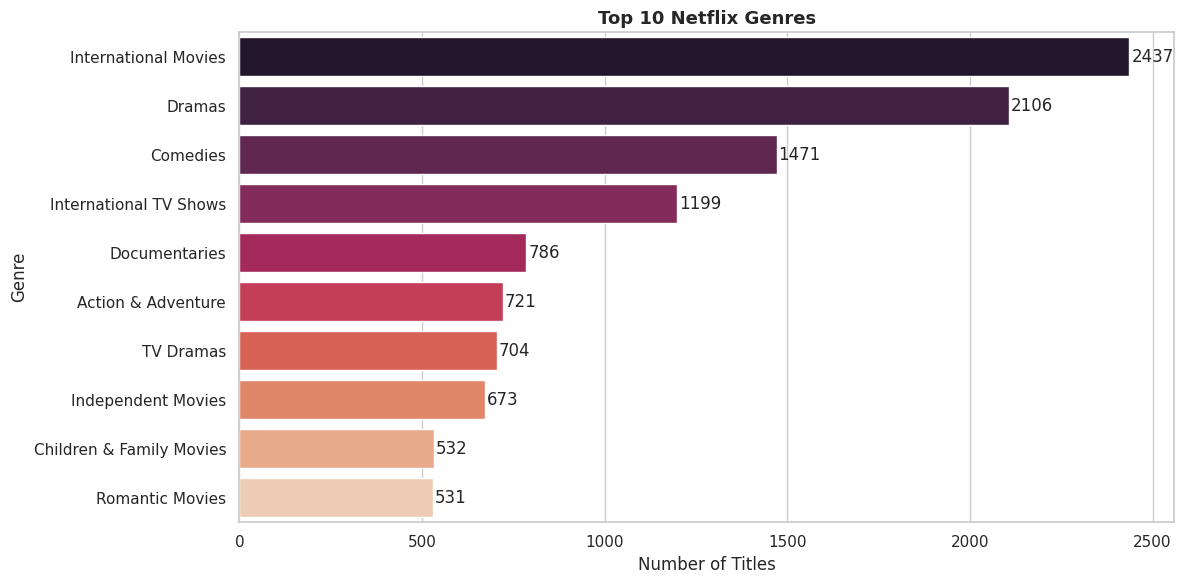

In [50]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=top10_genres.values,
    y=top10_genres.index,
    hue=top10_genres.index,
    palette='rocket',
    legend=False
)

for i, value in enumerate(top10_genres.values):
    ax.text(value + 5, i, str(value), va='center')

plt.title("Top 10 Netflix Genres")
plt.xlabel("Number of Titles")
plt.ylabel("Genre")
plt.tight_layout()
plt.show()

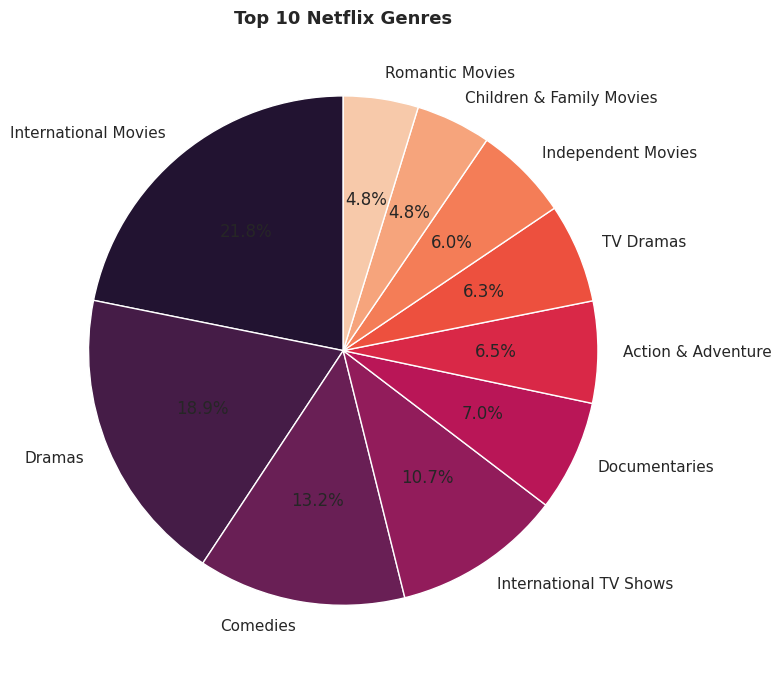

In [51]:
plt.figure(figsize=(8, 8))
plt.pie(
    top10_genres.values,
    labels=top10_genres.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=sns.color_palette('rocket', len(top10_genres))
)
plt.title("Top 10 Netflix Genres")
plt.tight_layout()
plt.show()

In [52]:
print("Most Popular Genre:", genre_counts.idxmax())
print("Number of Titles:", genre_counts.max())

Most Popular Genre: International Movies
Number of Titles: 2437


In [53]:
genre_percentage = round(genre_counts / genre_counts.sum() * 100, 2)
genre_percentage.head(10)

genres
International Movies        14.28
Dramas                      12.34
Comedies                     8.62
International TV Shows       7.02
Documentaries                4.60
Action & Adventure           4.22
TV Dramas                    4.12
Independent Movies           3.94
Children & Family Movies     3.12
Romantic Movies              3.11
Name: count, dtype: float64

## Interpretation
### Key Findings
1. **International Movies** is the most popular genre with **2,437** titles.
2. **Dramas** rank second with **2,106** titles.
3. **Comedies** are the third most common genre.
4. Netflix has a strong focus on international content, reflecting its strategy of serving a global
   audience rather than a single-market catalog.
5. Documentaries, Action & Adventure, and TV Dramas also make up a significant part of the library.

# Task 8: Duration Analysis

## Questions
1. Average movie duration.
2. Longest / shortest movie.
3. Distribution of movie duration.
4. *(Added)* Average number of seasons for TV Shows, and distribution.

**Important:** as established in Task 2, `duration` means minutes for Movies and seasons for TV Shows.
The two are analyzed **separately** below -- combining them would produce meaningless statistics.

In [54]:
movies   = df_clean[df_clean['type'] == 'Movie'].copy()
tv_shows = df_clean[df_clean['type'] == 'TV Show'].copy()

movies.rename(columns={'duration': 'duration_min'}, inplace=True)
tv_shows.rename(columns={'duration': 'seasons'}, inplace=True)

movies[['title', 'duration_min']].head()

,title,duration_min
1,1920,143
2,3 Heroines,124
3,Blue Mountain State: The Rise of Thadland,90
5,Blue Ruin,90
6,Blue Streak,94


### Movies -- Duration in Minutes

In [55]:
movies['duration_min'].describe()

count    5377.000000
mean       99.307978
std        28.530881
min         3.000000
25%        86.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration_min, dtype: float64

In [56]:
average_duration = movies['duration_min'].mean()
print("Average Movie Duration:", round(average_duration, 2), "minutes")

Average Movie Duration: 99.31 minutes


In [57]:
longest_movie = movies.loc[movies['duration_min'].idxmax()]
print(longest_movie[['title', 'duration_min']])

title           Black Mirror: Bandersnatch
duration_min                           312
Name: 7741, dtype: object


In [58]:
shortest_movie = movies.loc[movies['duration_min'].idxmin()]
print(shortest_movie[['title', 'duration_min']])

title           Silent
duration_min         3
Name: 5119, dtype: object


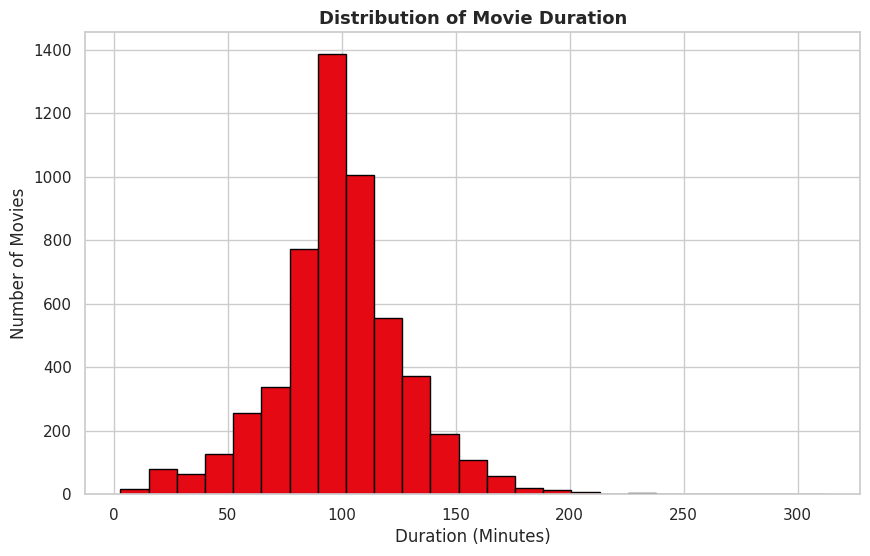

In [59]:
plt.figure(figsize=(10, 6))
plt.hist(movies['duration_min'], bins=25, edgecolor='black', color=NETFLIX_RED)
plt.title("Distribution of Movie Duration")
plt.xlabel("Duration (Minutes)")
plt.ylabel("Number of Movies")
plt.show()

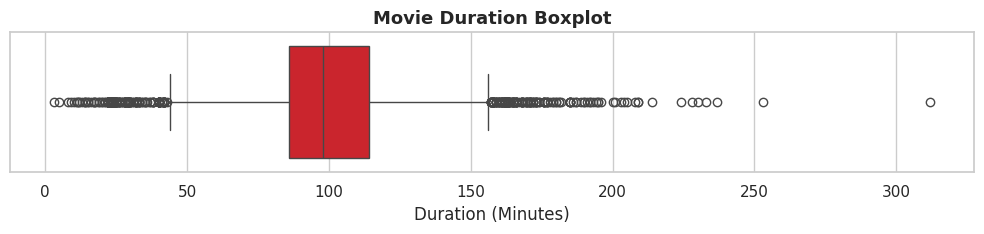

In [60]:
plt.figure(figsize=(10, 2.5))
sns.boxplot(x=movies['duration_min'], color=NETFLIX_RED)
plt.title("Movie Duration Boxplot")
plt.xlabel("Duration (Minutes)")
plt.tight_layout()
plt.show()

### TV Shows -- Number of Seasons *(added analysis)*

In [61]:
tv_shows['seasons'].describe()

count    2410.000000
mean        1.775934
std         1.596359
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        16.000000
Name: seasons, dtype: float64

In [62]:
avg_seasons = tv_shows['seasons'].mean()
most_seasons_show = tv_shows.loc[tv_shows['seasons'].idxmax()]

print("Average number of seasons:", round(avg_seasons, 2))
print("TV Show with the most seasons:", most_seasons_show['title'], "-", most_seasons_show['seasons'], "seasons")

Average number of seasons: 1.78
TV Show with the most seasons: Grey's Anatomy - 16 seasons


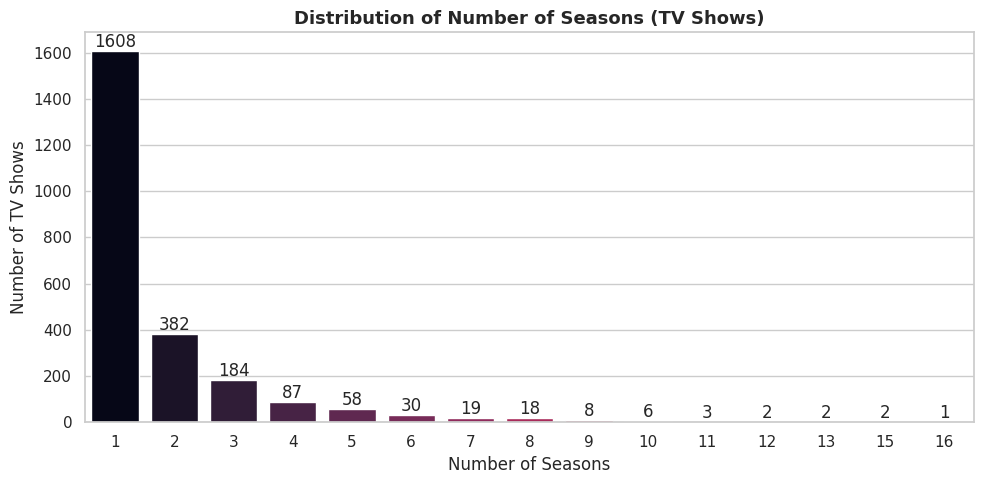

In [63]:
plt.figure(figsize=(10, 5))
ax = sns.countplot(
    data=tv_shows,
    x='seasons',
    hue='seasons',
    palette='rocket',
    legend=False
)
for container in ax.containers:
    ax.bar_label(container)
plt.title("Distribution of Number of Seasons (TV Shows)")
plt.xlabel("Number of Seasons")
plt.ylabel("Number of TV Shows")
plt.tight_layout()
plt.show()

## Interpretation
- The average movie duration is **99.31 minutes**, close to the standard feature-film length.
- The shortest movie is **3 minutes** long; the longest is **312 minutes**.
- Most movies fall within a moderate duration range, with only a few exceptionally short or long titles.
- The overwhelming majority of Netflix TV Shows have **just 1 season**, meaning most series are
  short-lived or newly launched rather than long-running franchises -- a useful signal for renewal /
  cancellation strategy discussions.

# Task 9: Outlier Analysis

## Using movie duration
1. Detect outliers using IQR.
2. Detect outliers using Z-score.
3. Compare results.

In [64]:
Q1 = movies['duration_min'].quantile(0.25)
Q3 = movies['duration_min'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: 44.0
Upper bound: 156.0


In [65]:
iqr_outliers = movies[
    (movies['duration_min'] < lower) |
    (movies['duration_min'] > upper)
]
print("Number of IQR Outliers:", len(iqr_outliers))

Number of IQR Outliers: 337


In [66]:
movies['z_score'] = zscore(movies['duration_min'])

In [67]:
z_outliers = movies[movies['z_score'].abs() > 3]
print("Number of Z-Score Outliers:", len(z_outliers))

Number of Z-Score Outliers: 45


In [68]:
print("IQR Outliers     :", len(iqr_outliers))
print("Z-Score Outliers :", len(z_outliers))

IQR Outliers     : 337
Z-Score Outliers : 45


## Interpretation
### Why the numbers differ
- **IQR** (337 outliers): flags any movie whose duration lies outside the normal interquartile range. It
  is more sensitive and catches many unusually short or long movies.
- **Z-Score** (45 outliers): only flags movies more than 3 standard deviations from the mean. It is
  stricter and identifies only the most extreme cases.

This difference is expected -- the two methods use different statistical criteria, and IQR is generally
preferred for skewed distributions (movie duration is right-skewed because of a handful of very long
titles), while Z-score assumes an approximately normal distribution.

# Task 10: Feature Engineering

### Create
- **Release Decade** -- 1980s / 1990s / 2000s / 2010s / 2020s
- **Content Age** -- Current Year - Release Year
- **Duration Category** (Movies only) -- Short / Medium / Long
- **Season Category** (TV Shows only, *added*) -- so the bug of applying minute-based bins to a
  season-count column (which would classify every TV Show as "Short") is avoided.

In [69]:
df_clean['Release Decade'] = pd.cut(
    df_clean['release_year'],
    bins=[1979, 1989, 1999, 2009, 2019, 2029],
    labels=['1980s', '1990s', '2000s', '2010s', '2020s']
)

df_clean['Release Decade'].value_counts().sort_index()

Release Decade
1980s     106
1990s     225
2000s     728
2010s    5711
2020s     899
Name: count, dtype: int64

In [70]:
current_year = 2026
df_clean['Content Age'] = current_year - df_clean['release_year']
df_clean[['release_year', 'Content Age']].head()

,release_year,Content Age
0,2020,6
1,2008,18
2,2016,10
3,2016,10
4,2017,9


**Fixing a subtle bug:** the `duration` column mixes minutes (Movies) and seasons (TV Shows).
Binning the *whole* column with minute-based thresholds (0-60-120-400) would silently mislabel every
TV Show as "Short" (since season counts are always small numbers). We therefore build the Duration
Category **from the Movies subset only**, and give TV Shows their own Season Category.

In [71]:
movies['Duration Category'] = pd.cut(
    movies['duration_min'],
    bins=[0, 60, 120, 400],
    labels=['Short', 'Medium', 'Long']
)

movies['Duration Category'].value_counts()

Duration Category
Medium    3920
Long      1011
Short      446
Name: count, dtype: int64

In [72]:
tv_shows['Season Category'] = pd.cut(
    tv_shows['seasons'],
    bins=[0, 1, 3, 100],
    labels=['Single Season', 'Few Seasons (2-3)', 'Long-Running (4+)']
)

tv_shows['Season Category'].value_counts()

Season Category
Single Season        1608
Few Seasons (2-3)     566
Long-Running (4+)     236
Name: count, dtype: int64

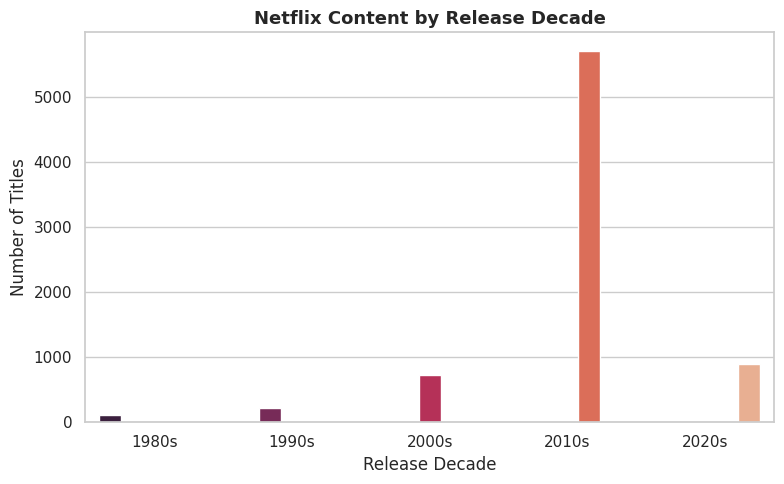

In [73]:
plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_clean,
    x='Release Decade',
    hue='Release Decade',
    order=['1980s', '1990s', '2000s', '2010s', '2020s'],
    palette='rocket',
    legend=False
)
plt.title("Netflix Content by Release Decade")
plt.xlabel("Release Decade")
plt.ylabel("Number of Titles")
plt.tight_layout()
plt.show()

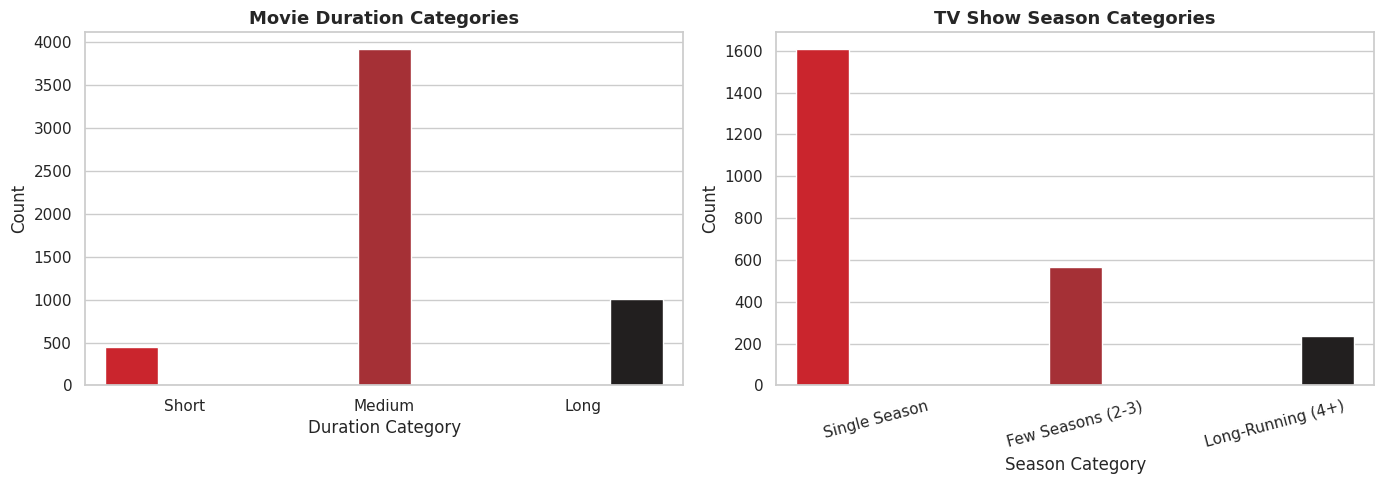

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(
    data=movies, x='Duration Category', hue='Duration Category',
    order=['Short', 'Medium', 'Long'], palette=PALETTE[:3], legend=False, ax=axes[0]
)
axes[0].set_title("Movie Duration Categories")
axes[0].set_xlabel("Duration Category")
axes[0].set_ylabel("Count")

sns.countplot(
    data=tv_shows, x='Season Category', hue='Season Category',
    order=['Single Season', 'Few Seasons (2-3)', 'Long-Running (4+)'],
    palette=PALETTE[:3], legend=False, ax=axes[1]
)
axes[1].set_title("TV Show Season Categories")
axes[1].set_xlabel("Season Category")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

## Interpretation
- **2010s** dominate the dataset with **5,711** titles -- Netflix's biggest content expansion happened
  during this decade.
- The **2020s** have fewer titles because the dataset only contains the early years of that decade.
- Medium-duration movies (60-120 min) are the largest category, roughly half of all movies -- standard
  feature-length films remain the platform's core offering.
- The large majority of TV Shows are **single-season** -- consistent with the seasons finding in Task 8,
  and a signal that most series never get renewed.

# Task 11: Multivariate Analysis

### Investigate
1. Content Type vs Rating
2. Content Type by Country
3. Movies released over time
4. Correlation among numeric features
5. *(Added)* Top directors and top actors by title count

### Use
Crosstab, Heatmaps, GroupBy

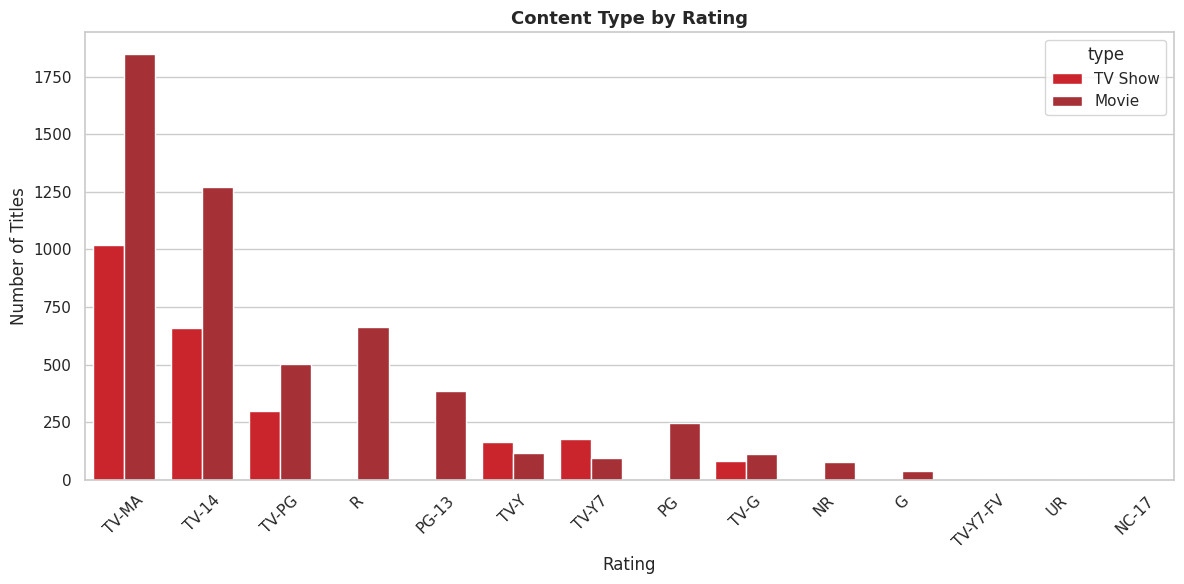

In [75]:
plt.figure(figsize=(12, 6))
sns.countplot(
    data=df_clean,
    x='rating',
    hue='type',
    order=df_clean['rating'].value_counts().index,
    palette=PALETTE[:2]
)
plt.title("Content Type by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Titles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Shows whether Movies or TV Shows dominate each maturity rating -- helpful for identifying the target audience of each content type.

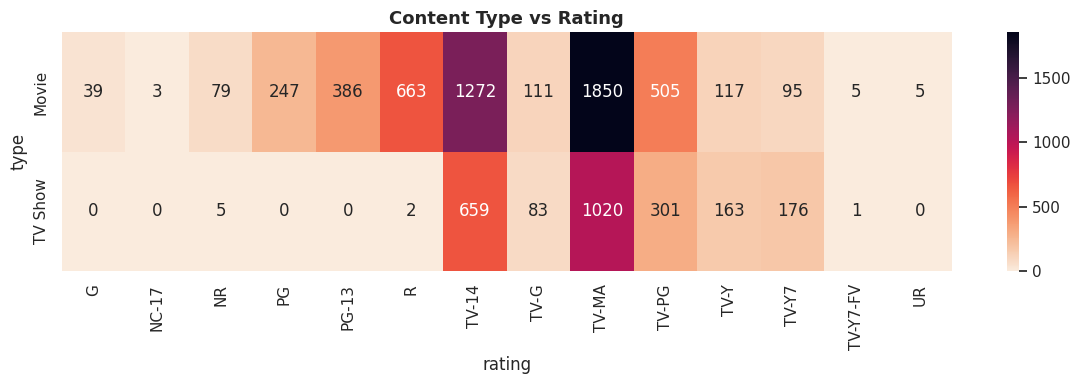

In [76]:
rating_type = pd.crosstab(df_clean['type'], df_clean['rating'])

plt.figure(figsize=(12, 4))
sns.heatmap(rating_type, annot=True, fmt='d', cmap='rocket_r')
plt.title("Content Type vs Rating")
plt.tight_layout()
plt.show()

Darker cells indicate higher concentrations -- easier to scan than a raw crosstab table.

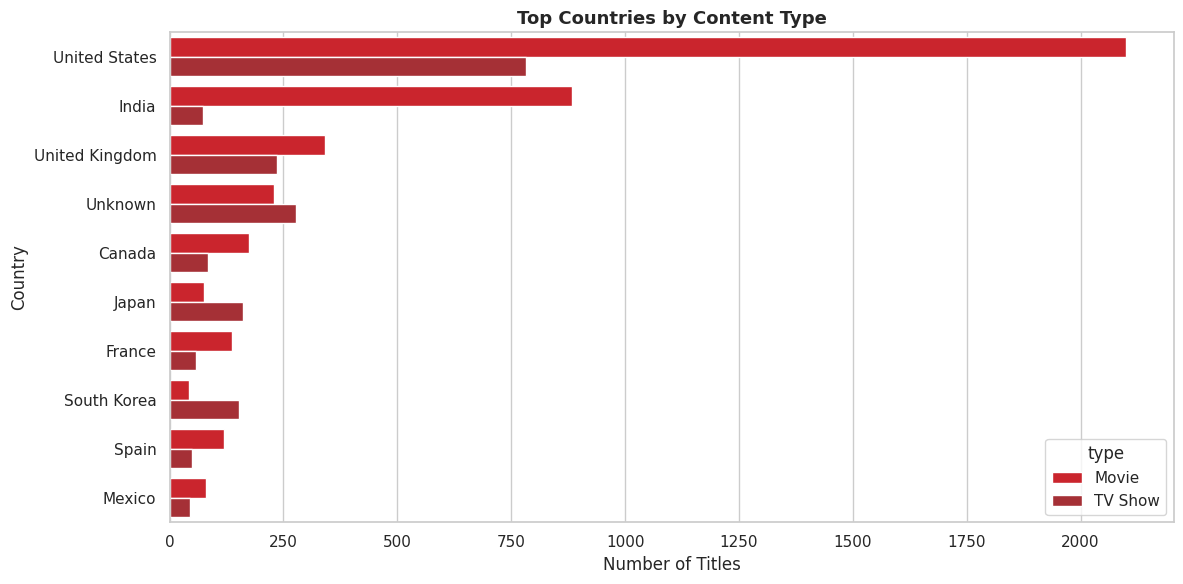

In [77]:
top10 = df_clean['primary_country'].value_counts().head(10).index
country_type = df_clean[df_clean['primary_country'].isin(top10)]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=country_type,
    y='primary_country',
    hue='type',
    order=top10,
    palette=PALETTE[:2]
)
plt.title("Top Countries by Content Type")
plt.xlabel("Number of Titles")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

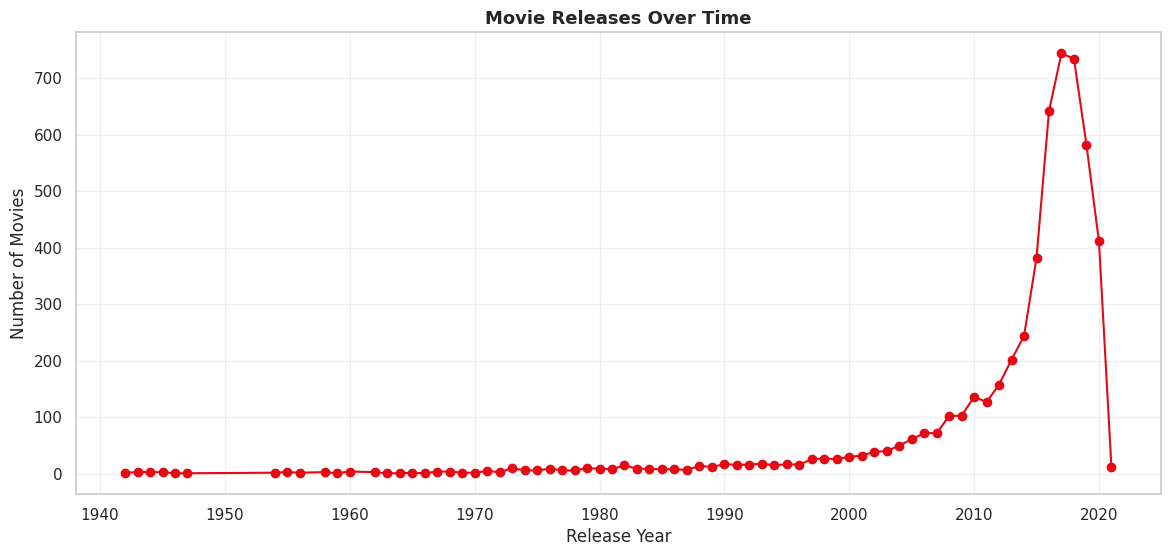

In [78]:
movie_year = movies['release_year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
plt.plot(movie_year.index, movie_year.values, marker='o', color=NETFLIX_RED)
plt.title("Movie Releases Over Time")
plt.xlabel("Release Year")
plt.ylabel("Number of Movies")
plt.grid(True, alpha=0.3)
plt.show()

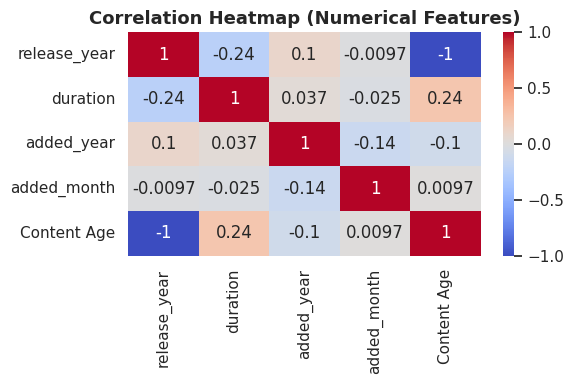

In [79]:
numeric_df = df_clean.select_dtypes(include=['number'])

plt.figure(figsize=(6, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Heatmap (Numerical Features)")
plt.tight_layout()
plt.show()

`release_year` and `Content Age` are perfectly (negatively) correlated by construction (`Content Age = current_year - release_year`) -- expected, and a good reminder that engineered features can be trivially collinear with their source column.

### Top Directors and Top Actors *(added)*

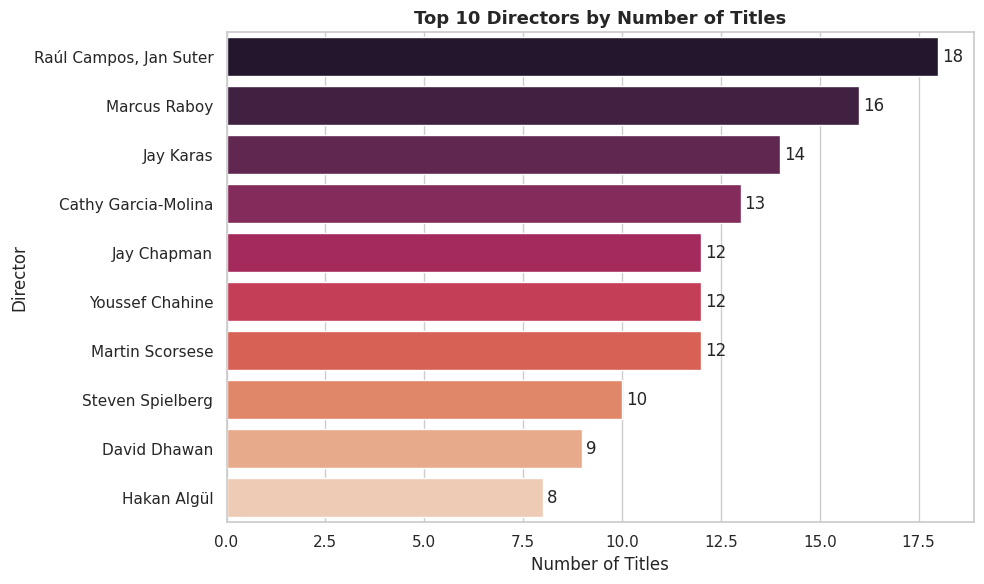

In [80]:
top_directors = (
    df_clean[df_clean['director'] != 'Unknown']['director']
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_directors.values, y=top_directors.index, hue=top_directors.index,
                  palette='rocket', legend=False)
for i, v in enumerate(top_directors.values):
    ax.text(v + 0.1, i, str(v), va='center')
plt.title("Top 10 Directors by Number of Titles")
plt.xlabel("Number of Titles")
plt.ylabel("Director")
plt.tight_layout()
plt.show()

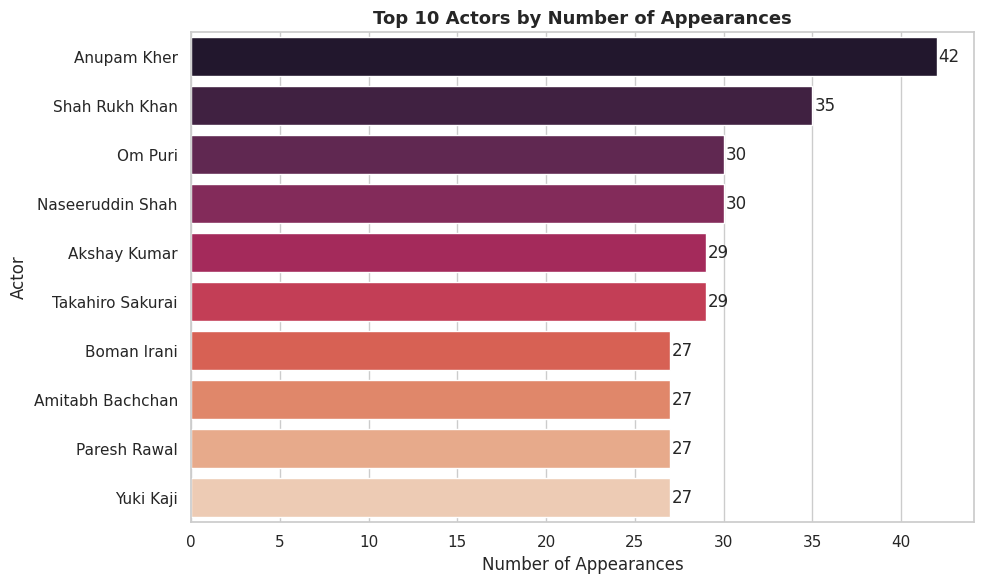

In [81]:
top_actors = (
    df_clean[df_clean['cast'] != 'Not Available']['cast']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(x=top_actors.values, y=top_actors.index, hue=top_actors.index,
                  palette='rocket', legend=False)
for i, v in enumerate(top_actors.values):
    ax.text(v + 0.1, i, str(v), va='center')
plt.title("Top 10 Actors by Number of Appearances")
plt.xlabel("Number of Appearances")
plt.ylabel("Actor")
plt.tight_layout()
plt.show()

## Interpretation
- Movies substantially outnumber TV Shows in almost every rating bracket, confirming the movie-heavy
  catalog seen in Task 3.
- Content contributions are concentrated in a handful of countries even after breaking out by type.
- The numeric correlation heatmap contains no surprising relationships once the trivial
  `release_year` / `Content Age` collinearity is set aside.
- A small number of directors and actors are associated with a disproportionately large share of titles,
  which is useful for talent-relationship and negotiation prioritization.

# Task 12: Business Insights & Recommendations

Rather than hardcoding numbers into markdown text (which silently goes stale if the data changes), the key figures below are pulled live from the variables computed earlier in the notebook.

In [82]:
print("KEY METRICS SUMMARY")
print("=" * 40)
print(f"Total titles                : {df_clean.shape[0]}")
print(f"Movies                      : {movies_count} ({content_pct['Movie']}%)")
print(f"TV Shows                    : {tv_count} ({content_pct['TV Show']}%)")
print(f"Top producing country       : {top_countries.index[0]} ({top_countries.iloc[0]} titles)")
print(f"Second producing country    : {top_countries.index[1]} ({top_countries.iloc[1]} titles)")
print(f"Most popular genre          : {genre_counts.idxmax()} ({genre_counts.max()} titles)")
print(f"Peak release year           : {peak_year} ({peak_count} titles)")
print(f"Most common rating          : {most_common_rating} ({rating_counts.iloc[0]} titles)")
print(f"Average movie duration      : {round(average_duration, 1)} minutes")
print(f"Average TV show seasons     : {round(avg_seasons, 1)}")
print(f"IQR duration outliers       : {len(iqr_outliers)}")
print(f"Top director                : {top_directors.index[0]} ({top_directors.iloc[0]} titles)")

KEY METRICS SUMMARY
Total titles                : 7787
Movies                      : 5377 (69.05%)
TV Shows                    : 2410 (30.95%)
Top producing country       : United States (2883 titles)
Second producing country    : India (956 titles)
Most popular genre          : International Movies (2437 titles)
Peak release year           : 2018 (1121 titles)
Most common rating          : TV-MA (2870 titles)
Average movie duration      : 99.3 minutes
Average TV show seasons     : 1.8
IQR duration outliers       : 337
Top director                : Raúl Campos, Jan Suter (18 titles)


## Business Insights
1. **Movies dominate the catalog** (69% of titles) — Netflix's acquisition strategy has historically
   leaned toward films over series.
2. **The US and India are the two largest content sources**, with India a distant-but-clear second —
   underscoring the importance of the Indian market for regional content investment.
3. **International Movies is the single largest genre**, reinforcing a deliberate global-audience
   content strategy rather than a US-centric one.
4. **2018 was the peak release year**, and the 2010s account for the majority of all titles — most of
   the catalog is relatively recent content, not legacy titles.
5. **TV-MA is the most common rating** — the platform skews toward adult content, which has implications
   for family-plan and parental-control positioning.
6. **Most TV Shows have only one season** — renewal rates are low; a large share of series-format
   investment does not turn into long-running franchises.
7. **Outlier duration titles are rare** (under 1% by Z-score) — the catalog is largely standardized
   around conventional movie lengths, aside from a handful of very short or very long outliers.

## Strategic Recommendations
1. **Continue investing in international and regional content** (especially Indian productions), since
   it is already one of the platform's strongest categories.
2. **Diversify further into emerging markets** beyond the current top contributors to reduce
   concentration risk in content sourcing.
3. **Re-evaluate the low season-renewal rate for TV Shows** — investigate whether single-season series
   under-perform on engagement, or whether this reflects a deliberate anthology / limited-series strategy
   worth doubling down on.
4. **Increase family-friendly (G/PG/TV-Y) content share** to broaden the addressable audience beyond the
   current adult-skewed catalog.
5. **Use engagement/viewership data (not available in this catalog dataset) alongside these catalog-level
   findings** before making investment decisions — this analysis describes *what exists on the platform*,
   not *what performs well*, and the two should not be conflated.

# Task 13: Conclusion

## Summary
This project walked through a complete mini data-analysis pipeline on the Netflix titles dataset:

- **Cleaned** a real-world dataset with missing values across five columns, converted dates, and
  standardized text fields.
- **Caught and fixed a unit-mixing issue** in the `duration` column (minutes for Movies vs. seasons for
  TV Shows) that would otherwise have silently corrupted the duration and duration-category analyses.
- **Explored** content type, country, yearly trends, ratings, genres, duration and multivariate
  relationships, each backed by a chart and a written interpretation.
- **Engineered new features** (Release Decade, Content Age, Duration/Season Category) to enable further
  analysis.
- **Detected outliers** using two independent statistical methods and explained why they disagree.
- **Converted findings into business insights and recommendations**, computed dynamically from the
  underlying data rather than hardcoded.

## Limitations
- The dataset is a catalog snapshot (no viewership, ratings/popularity, or subscriber data), so all
  insights describe *what is on the platform*, not *what audiences actually watch*.
- The data appears to end around 2021, so no post-2021 trends can be inferred.
- `country`, `director` and `cast` still contain an "Unknown" / "Not Available" placeholder for missing
  values — analyses involving these fields slightly undercount the true totals for those categories.

## Possible Next Steps
- Join with a viewership/engagement dataset to distinguish *catalog volume* from *audience demand*.
- Build a simple content-based recommender using the `genres` and `description` fields.
- Apply NLP/sentiment analysis on `description` to see whether tone correlates with genre or rating.


In [83]:
# Save the cleaned dataset as a deliverable of this project
df_clean.to_csv("NetFlix_cleaned.csv", index=False)
print("Cleaned dataset saved as NetFlix_cleaned.csv with shape:", df_clean.shape)

Cleaned dataset saved as NetFlix_cleaned.csv with shape: (7787, 18)
